In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_m0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/comparing_models/fold0_model0_results.tsv", sep="\t")

fold0_m0["model"] = [0 for i in range(len(fold0_m0))]
fold0_m0["fold"] = [0 for i in range(len(fold0_m0))]
fold0_m0["target"] = [-0.5 for i in range(len(fold0_m0))]

In [3]:
fold0_m1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/comparing_models/fold0_model1_results.tsv", sep="\t")

fold0_m1["model"] = [1 for i in range(len(fold0_m1))]
fold0_m1["fold"] = [0 for i in range(len(fold0_m1))]
fold0_m1["target"] = [-0.5 for i in range(len(fold0_m1))]

In [4]:
fold0_m2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/comparing_models/fold0_model2_results.tsv", sep="\t")

fold0_m2["model"] = [2 for i in range(len(fold0_m2))]
fold0_m2["fold"] = [0 for i in range(len(fold0_m2))]
fold0_m2["target"] = [-0.5 for i in range(len(fold0_m2))]

In [5]:
fold1_m0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/comparing_models/fold1_model0_results.tsv", sep="\t")

fold1_m0["model"] = [0 for i in range(len(fold1_m0))]
fold1_m0["fold"] = [1 for i in range(len(fold1_m0))]
fold1_m0["target"] = [-0.5 for i in range(len(fold1_m0))]

In [6]:
fold1_m1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/comparing_models/fold1_model1_results.tsv", sep="\t")

fold1_m1["model"] = [1 for i in range(len(fold1_m1))]
fold1_m1["fold"] = [1 for i in range(len(fold1_m1))]
fold1_m1["target"] = [-0.5 for i in range(len(fold1_m1))]

In [7]:
fold1_m2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/comparing_models/fold1_model2_results.tsv", sep="\t")

fold1_m2["model"] = [2 for i in range(len(fold1_m2))]
fold1_m2["fold"] = [1 for i in range(len(fold1_m2))]
fold1_m2["target"] = [-0.5 for i in range(len(fold1_m2))]

In [8]:
fold2_m0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/comparing_models/fold2_model0_results.tsv", sep="\t")

fold2_m0["model"] = [0 for i in range(len(fold2_m0))]
fold2_m0["fold"] = [2 for i in range(len(fold2_m0))]
fold2_m0["target"] = [-0.5 for i in range(len(fold2_m0))]

In [9]:
fold2_m1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/comparing_models/fold2_model1_results.tsv", sep="\t")

fold2_m1["model"] = [1 for i in range(len(fold2_m1))]
fold2_m1["fold"] = [2 for i in range(len(fold2_m1))]
fold2_m1["target"] = [-0.5 for i in range(len(fold2_m1))]

In [10]:
fold2_m2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/comparing_models/fold2_model2_results.tsv", sep="\t")

fold2_m2["model"] = [2 for i in range(len(fold2_m2))]
fold2_m2["fold"] = [2 for i in range(len(fold2_m2))]
fold2_m2["target"] = [-0.5 for i in range(len(fold2_m2))]

In [12]:
df = pd.concat([fold0_m0, fold0_m1, fold0_m2,
                 fold1_m0, fold1_m1, fold1_m2,
                 fold2_m0, fold2_m1, fold2_m2], ignore_index=True)

In [14]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [13]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'URQ_result', 'URQ_target', 'URQ_init', 'num_edits', 'GC_seq',
       'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'model', 'target'],
      dtype='object')

In [16]:
# Pivot so that each model is a column, preserving order within each fold
pivoted = df.pivot_table(index=['fold'], columns='model', values='URQ_diff', aggfunc=list)

# Combine across folds (flatten the lists)
combined = pd.DataFrame({
    'm0': sum(pivoted[0].dropna(), []),
    'm1': sum(pivoted[1].dropna(), []),
    'm2': sum(pivoted[2].dropna(), []),
})

# Compute Pearson correlations
r01, _ = pearsonr(combined['m0'], combined['m1'])
r02, _ = pearsonr(combined['m0'], combined['m2'])

In [17]:
print(f"Pearson R (model 0 vs 1): {r01:.3f}")
print(f"Pearson R (model 0 vs 2): {r02:.3f}")

Pearson R (model 0 vs 1): 0.936
Pearson R (model 0 vs 2): 0.944


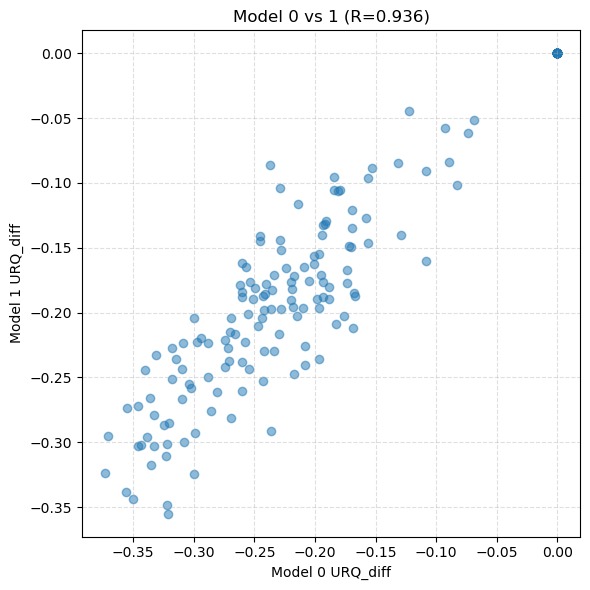

In [18]:
# --- Scatter Plot 1: Model 0 vs 1 ---
plt.figure(figsize=(6, 6))
plt.scatter(combined['m0'], combined['m1'], alpha=0.5)
plt.title(f'Model 0 vs 1 (R={r01:.3f})')
plt.xlabel('Model 0 URQ_diff')
plt.ylabel('Model 1 URQ_diff')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

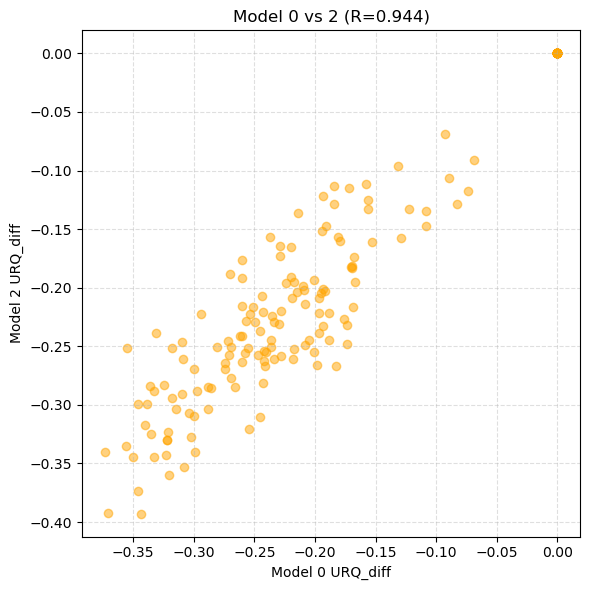

In [19]:
# --- Scatter Plot 2: Model 0 vs 2 ---
plt.figure(figsize=(6, 6))
plt.scatter(combined['m0'], combined['m2'], alpha=0.5, color='orange')
plt.title(f'Model 0 vs 2 (R={r02:.3f})')
plt.xlabel('Model 0 URQ_diff')
plt.ylabel('Model 2 URQ_diff')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()